# Final comparison

Cross-strategy comparison of accuracy (overall + per question type). Each strategy is detailed in its own notebook under `strategies/`; here we only compare the numbers.

To add a strategy: run its eval to a `results_*.json` file and add one line to `RESULTS` below.

In [1]:
import json, os
import matplotlib.pyplot as plt

OUT = '../outputs'

# label -> results json (extend as strategies are added)
RESULTS = {
    'A: no-RAG':          OUT + '/results.json',
    'B1: top1 + first3':  OUT + '/results_rag.json',
    'B2: all sections':  OUT + '/results_B2.json',
    'B3: top-k + rerank with clip':OUT + '/results_B3.json',
    'B4: top-k + rerank with cross':OUT + '/results_B4.json',
    # 'C: agentic RAG':    OUT + '/results_C.json',
}

loaded = {k: json.load(open(p)) for k, p in RESULTS.items() if os.path.exists(p)}
for k, r in loaded.items():
    print('%-20s overall %.4f (n=%d)' % (k, r['accuracy_overall'], r['num_examples']))
missing = [k for k in RESULTS if k not in loaded]
if missing:
    print('pending:', ', '.join(missing))

A: no-RAG            overall 0.2450 (n=1000)
B1: top1 + first3    overall 0.2780 (n=1000)
B2: all sections     overall 0.2950 (n=1000)
B3: top-k + rerank with clip overall 0.2430 (n=1000)
B4: top-k + rerank with cross overall 0.3600 (n=1000)


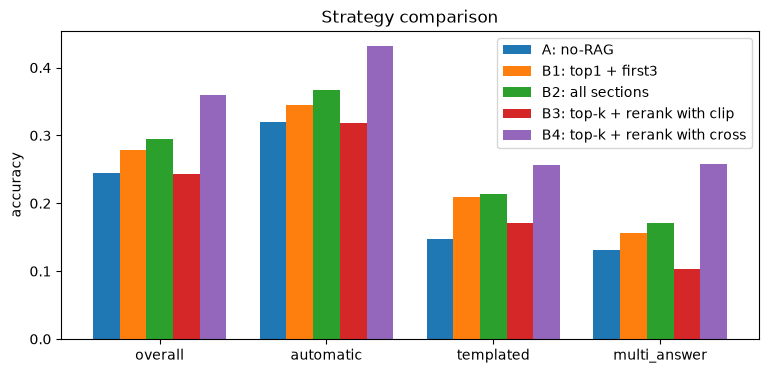

In [2]:
types = ['automatic', 'templated', 'multi_answer']
metrics = ['overall'] + types

def vals(r):
    return [r['accuracy_overall']] + [r['accuracy_by_type'].get(t, 0) for t in types]

keys = list(loaded)
n = max(len(keys), 1)
x = range(len(metrics)); w = 0.8 / n
plt.figure(figsize=(9, 4))
for i, k in enumerate(keys):
    off = (i - (n - 1) / 2) * w
    plt.bar([j + off for j in x], vals(loaded[k]), w, label=k)
plt.xticks(list(x), metrics); plt.ylabel('accuracy')
plt.title('Strategy comparison'); plt.legend()
plt.show()

**Reading the chart.** `A` is the no-RAG floor. Each `B*` is a RAG variant aiming for a solid baseline. `C` (agentic RAG) is the target contribution that must beat the best `B`.